# Predict-then-optimise with quarterly PD and Basel IRB (revised)

The model predicts next-quarter PD `PD_Q_{t+1} = c_q_{t+1} / LGD`, quarterly PD drives the expected quarterly loss/return component, and annualised PD enters the Basel IRB capital requirement.

Choices of note:

- `CHARGE_OFF_CONVERSION` defaults to `"simple"`: FRED annualises quarterly net charge-off
  rates by a simple x4, so dividing by 4 is the correct inverse of the source convention
  (`"compound"` retained as an option);
- the current-quarter charge-off `c_q` is added as a feature (it is realised by decision
  time, subject to a reporting lag), alongside `c_q_lag1`; constructed PD columns remain
  excluded as features;
- models train on logit-transformed quarterly PD by default (`TARGET_TRANSFORM = "logit"`),
  which puts the tiny PD targets on a well-scaled unbounded scale; predictions map back
  through a sigmoid;
- the output-bias initialisation uses only the pre-validation training slice, so validation
  targets never influence initialisation;
- training mini-batches are shuffled (the train/validation split stays chronological);
- the MLP is a small seed ensemble (`MLP_SEEDS`), reported as the mean prediction with the
  cross-seed standard deviation stored per test date;
- the Basel corporate PD floor (0.03%) is applied inside `k_irb_from_annual_pd` (toggleable);
- a persistence baseline (`pd_q_hat = c_q_t / LGD`) runs through the identical decision
  pipeline as a reference;
- two expanding-window evaluation splits: `modern` (final 25% of the sample, as before) and
  `stress` (test targets from 2006Q1 onward, so the GFC is out-of-sample);
- out-of-sample forecast accuracy (RMSE/MAE/bias) and pairwise Diebold-Mariano tests, on
  squared PD errors and on per-period regret;

In [6]:
from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

FIGURES_DIR = ROOT / "empirical" / "figures" / "pto"
RESULTS_DIR = ROOT / "empirical" / "results" / "pto"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: figures/pto_pd_irb_v2
Results: empirical/results/pto


## Configuration

`CHARGE_OFF_CONVERSION = "simple"` inverts FRED's simple x4 annualisation, which is the
correct inverse for these series; `"compound"` remains available if the source were treated
as a compounded annual rate (the numerical difference at these PD levels is under 1%
relative). `TARGET_TRANSFORM = "logit"` trains on logit(PD) with a raw-score output head;
set `"level"` to reproduce the original sigmoid + level-space MSE behaviour.
`MLP_SEEDS` controls the ensemble size; MLP runtime scales linearly in the number of seeds.
The `stress` split retrains from 2006Q1 onward and roughly doubles total runtime — drop it
from `EVAL_SPLITS` for quick iterations.

In [7]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
CHARGE_OFF_CONVERSION = "simple" # FRED annualises quarterly net charge-offs with a simple x4
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Feature policy: the current-quarter charge-off c_q is realised by decision time
# (start of t+1), modulo a reporting lag. Set False to revert to lag-1 only.
INCLUDE_CURRENT_CQ = True

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0

# Basel corporate PD floor (0.03%), applied inside k_irb_from_annual_pd.
APPLY_PD_FLOOR = True
PD_FLOOR = 3e-4

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, 101)

# Modelling choices
TARGET_TRANSFORM = "logit"  # "logit" or "level" (original behaviour)
MLP_SEEDS = (42, 43, 44, 45, 46)  # MLP seed ensemble; use (42,) to disable

# Training loss. "nll_vasicek" fits PD by maximum likelihood under the assumption that
# realised charge-off rates are Vasicek draws given PD, with correlation = Basel R times
# NLL_RHO_SCALE. Unlike logit-space MSE (which targets the conditional MEDIAN of the
# realisation), the NLL targets the MEAN PD. Caveat: the aggregate FRED series,
# conditioned on rich macro features, carries far less residual noise than full Basel
# rho implies, so NLL_RHO_SCALE = 1.0 may inflate small PDs (roughly by the inverse
# median map, ~2-2.5x at rho ~ 0.2). Reduce NLL_RHO_SCALE or set LOSS = "mse" to compare.
LOSS = "mse"  # "nll_vasicek" or "mse"
# "auto" estimates the residual probit-space variance per training window (OLS, no
# look-ahead) and sets rho_eff = s2 / (1 + s2): the likelihood noise the data actually
# exhibits given the features. Recommended for the aggregate FRED series, where full
# Basel rho drastically overstates residual noise and inflates predictions ~2-2.5x.
# "basel" uses rho = NLL_RHO_SCALE * BaselR(pd_a_hat).
NLL_RHO_MODE = "auto"  # "auto" or "basel"
NLL_RHO_SCALE = 1.0    # only used when NLL_RHO_MODE == "basel"

# Evaluation splits: separate expanding-window experiments.
EVAL_SPLITS = {
    "modern": {"initial_train_frac": 0.75},
    "stress": {"first_test_date": "2006-01-01"},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()

## Assumptions and caveats

These are held fixed by design; each materially shapes the results and should be restated
wherever results are reported.

- **Constant LGD = 0.45.** Realised PD is backed out as `c_q / LGD`, so "PD" here is a
  rescaled charge-off rate. LGD is procyclical in reality and Basel requires downturn LGD.
- **Corporate IRB curve on an aggregate charge-off series.** The asset-correlation function,
  maturity adjustment, and 0.03% floor are the wholesale/corporate ones. If the underlying
  FRED series is retail/consumer, the retail risk-weight functions (different correlation,
  no maturity adjustment) would apply.
- **Point-in-time PD in a through-the-cycle formula.** Next-quarter PD is annualised as
  `1-(1-pd_q)^4` (independence across quarters) and fed into the IRB formula, making capital
  procyclical; Basel intends TTC PDs.
- **Constant quarterly yield `Y_BAR` and constant leverage** regardless of the rate
  environment.
- **Final-vintage macro data.** Features use revised series, and quarter-t values (e.g. GDP)
  are not published until well into t+1 — a mild look-ahead relative to real-time
  deployment. Including `c_q` as a feature likewise assumes the quarter-t charge-off is
  observable at decision time; set `INCLUDE_CURRENT_CQ = False` to enforce a full
  one-quarter reporting lag.
- **Oracle regret** uses per-period perfect foresight of both `c_q` and the annualised PD
  entering the capital requirement, so regret mixes forecast error with capital-requirement
  foresight.
- **Capital buffer add-on.** Committed capital is excluded from the available buffer;
  equivalently the requirement is `K_IRB + 1/LEVERAGE` per unit exposure, i.e. the
  regulatory minimum plus a fixed management buffer. Calibrated so the constraint binds
  in the interior of the allocation range - without it the constraint never binds for
  alpha in [0,1] and the decision is degenerate at alpha = 1.

## Quarterly PD, Basel IRB, and allocation objective

In [8]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1, lgd=LGD, m=M):
    # U(alpha; c_q, pd_a), with pd_a used only for Basel IRB capital.
    # Buffer semantics (intentional): committed capital alpha*k1 is excluded from the
    # available buffer. Algebraically identical to requiring K_IRB plus a fixed
    # management buffer add-on of 1/LEVERAGE per unit exposure; this is what makes the
    # capital constraint bind in the interior of the alpha grid (without it the
    # constraint never binds on [0,1] and every model would choose alpha = 1).
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a, lgd=lgd, m=m) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, pd_a):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=k_irb)


def optimise_alpha_grid(c_q, pd_a, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, pd_a=pd_a)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])

## Load and align data

The forecasting row is `x_t -> PD_Q_{t+1}`; result columns are named for the realised
next-period outcome, because that is the period used for decision evaluation.

Features now include the current-quarter charge-off `c_q` (realised by decision time,
subject to a reporting lag — see the assumptions cell) alongside `c_q_lag1`. Constructed PD
columns (`pd_q`, `pd_a`) remain excluded: realised PD is built from charge-offs for the
target/evaluation convention, not treated as an observed signal.

In [9]:
def load_quarterly_pd_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signals. PD columns are never features.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    if feature_cols is None:
        exclude = {date_col, "c_annual_raw", "c_annual_decimal", "pd_q", "pd_a", "target_date",
                   "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"}
        if not INCLUDE_CURRENT_CQ:
            exclude.add("c_q")
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + ["c_q", "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"]
    required = list(dict.fromkeys(required))
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")
    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "empirical" / "data" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv"
df = load_quarterly_pd_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


## Models and training loop

Both models output a raw score whose sigmoid is the predicted quarterly PD. The loss
is selected by `LOSS`: Vasicek negative log-likelihood on probit targets (default;
targets the mean PD under the assumed Vasicek realisation noise) or MSE on
logit/level targets. Under `LOSS = "mse"`,
`TARGET_TRANSFORM` picks logit-space targets (well-conditioned) or level-space
targets (the original objective).
The output bias is initialised at logit(mean PD) of the pre-validation slice only.
Mini-batches are shuffled with a seeded generator; the train/validation split itself
remains chronological.

In [10]:
def logit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return np.log(p / (1.0 - p))


def probit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return norm.ppf(p)


def torch_vasicek_nll(score, y_probit, rho_fixed=None):
    """Negative log-likelihood of realised rates under the Vasicek density,
    parameterised by the model's predicted PD (sigmoid of the raw score).

    In probit space the Vasicek model is Gaussian:
        ndtri(x) | p ~ N( ndtri(p) / sqrt(1 - rho), rho / (1 - rho) ),
    with rho = NLL_RHO_SCALE * BaselR(annualised p). Terms not involving the
    prediction are dropped, except the log-variance, which depends on p through rho.
    Maximising this likelihood targets the MEAN parameter p.
    """
    pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    if rho_fixed is not None:
        rho = torch.as_tensor(float(rho_fixed))
    else:
        pd_a = (1.0 - torch.pow(1.0 - pd_q, 4.0)).clamp(PD_A_CLIP_LOW, PD_A_CLIP_HIGH)
        exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - float(np.exp(-50.0)))
        rho = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
        rho = torch.clamp(NLL_RHO_SCALE * rho, 1e-4, 0.999)
    mu = torch.special.ndtri(pd_q) / torch.sqrt(1.0 - rho)
    var = rho / (1.0 - rho)
    return torch.mean(0.5 * torch.log(var) + (y_probit - mu) ** 2 / (2.0 * var))


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    # Bias starts at logit(mean PD) of the PRE-validation slice only, so validation
    # targets used for early stopping never influence initialisation.
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, seed=None, return_history=False):
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    if LOSS == "nll_vasicek":
        t_tr, t_val = probit_np(y_tr), probit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "logit":
        t_tr, t_val = logit_np(y_tr), logit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "level":
        t_tr, t_val = y_tr, y_val
    else:
        raise ValueError("LOSS must be 'nll_vasicek' or 'mse'; TARGET_TRANSFORM must be 'logit' or 'level'.")

    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(t_tr, dtype=torch.float32))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_tr)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    mse_fn = nn.MSELoss()

    rho_fixed = None
    if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto":
        # Residual probit-space variance of the training window (pre-validation slice),
        # via OLS with intercept: rho_eff = s2 / (1 + s2) is the Vasicek correlation
        # implied by the noise the data actually shows given the features.
        X_ols = np.hstack([x_tr, np.ones((len(x_tr), 1))])
        beta_ols, *_ = np.linalg.lstsq(X_ols, t_tr, rcond=None)
        resid = t_tr - X_ols @ beta_ols
        dof = max(len(t_tr) - X_ols.shape[1], 1)
        s2 = float(resid @ resid) / dof
        rho_fixed = float(np.clip(s2 / (1.0 + s2), 1e-4, 0.5))

    def compute_loss(score, target):
        if LOSS == "nll_vasicek":
            return torch_vasicek_nll(score, target, rho_fixed=rho_fixed)
        pred = score if TARGET_TRANSFORM == "logit" else torch.sigmoid(score)
        return mse_fn(pred, target)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    t_val_t = torch.tensor(t_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, tb in train_loader:
            optimiser.zero_grad()
            loss = compute_loss(model(xb), tb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_loss = compute_loss(score_val, t_val_t).item()
            pd_q_val_np = clip_pd_q(torch.sigmoid(score_val).cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "seed": seed,
                        "rho_eff": float("nan") if rho_fixed is None else rho_fixed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val, stale_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def train_mlp_ensemble(x_train, y_train_pd_q, model_cfg, seeds=MLP_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_pd_model(x_train, y_train_pd_q, "mlp", model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## Expanding-window evaluation

At each test date the scaler and models are refit on observations strictly before the
feature date. Three predictors run through the identical decision pipeline: the linear
model, the MLP seed ensemble (mean prediction), and a persistence baseline
`pd_q_hat = c_q_t / LGD`. Persistence is the reference point: a trained model that does not
beat it on regret adds no decision value over "assume next quarter looks like this quarter".

Two splits run as separate experiments: `modern` (last 25% of the sample) and `stress`
(test targets from 2006Q1, so the GFC is out-of-sample). The modern test window is contained
in the stress one; they are not independent samples.

In [11]:
def build_result_row(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    alpha_hat, _ = optimise_alpha_grid(c_q=c_q_hat, pd_a=pd_a_hat)
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat, "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        linear_model, linear_hist = train_pd_model(x_train, y_train, "linear", model_cfg, return_history=True)
        records.append(build_result_row(test_row, float(predict_pd_q(linear_model, x_test)[0]), "linear", split_name))

        mlp_models, mlp_hist = train_mlp_ensemble(x_train, y_train, model_cfg, return_history=True)
        mlp_mean, mlp_std = predict_pd_q_ensemble(mlp_models, x_test)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))

        # Persistence baseline: current-quarter implied PD carried forward, no training.
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c_q"] / LGD)), "persistence", split_name))

        if return_history:
            for hist in (linear_hist, mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["split"] = split_name
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[modern] first test target: 2017-04-01, 36 windows, 106 initial training obs
[modern] completed 5/36 windows (38s elapsed)
[modern] completed 10/36 windows (76s elapsed)
[modern] completed 15/36 windows (103s elapsed)
[modern] completed 20/36 windows (120s elapsed)
[modern] completed 25/36 windows (139s elapsed)
[modern] completed 30/36 windows (164s elapsed)
[modern] completed 35/36 windows (185s elapsed)
[modern] completed 36/36 windows (190s elapsed)
[stress] first test target: 2006-01-01, 81 windows, 61 initial training obs
[stress] completed 5/81 windows (19s elapsed)
[stress] completed 10/81 windows (33s elapsed)
[stress] completed 15/81 windows (42s elapsed)
[stress] completed 20/81 windows (49s elapsed)
[stress] completed 25/81 windows (59s elapsed)
[stress] completed 30/81 windows (74s elapsed)
[stress] completed 35/81 windows (89s elapsed)
[stress] completed 40/81 windows (112s elapsed)
[stress] completed 45/81 windows (144s elapsed)
[stress] completed 50/81 windows (181s ela

,split,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,modern,linear,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.002278,...,0.068577,0.071300,0.65,0.64,1.103187,1.101600,0.001588,0.0,0.000000,0.0
1,modern,mlp,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.002464,...,0.068577,0.073375,0.65,0.63,1.103187,1.100013,0.003175,0.0,0.000000,0.0
2,modern,persistence,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.001889,...,0.068577,0.066343,0.65,0.66,1.103187,1.026428,0.076760,0.0,0.007835,0.0
3,modern,linear,2017-07-01,2017-04-01,0.34,0.000850,0.000850,0.001889,0.007534,0.001775,...,0.066343,0.064707,0.66,0.67,1.105270,1.030554,0.074716,0.0,0.007631,0.0
4,modern,mlp,2017-07-01,2017-04-01,0.34,0.000850,0.000850,0.001889,0.007534,0.001573,...,0.066343,0.061537,0.66,0.68,1.105270,0.881757,0.223513,0.0,0.022670,0.0


## Result collection

One wide, thesis-facing frame per split; `_persistence` columns sit alongside the model
columns so the baseline flows through every downstream table and figure.

In [12]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["linear", "mlp", "persistence"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"pto_quarterly_pd_irb_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["modern"].head())

[modern] saved 36 rows to empirical/results/pto/pto_quarterly_pd_irb_predictions_modern.csv
[stress] saved 81 rows to empirical/results/pto/pto_quarterly_pd_irb_predictions_stress.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_linear,...,k_irb_hat_persistence,alpha_hat_linear,alpha_hat_mlp,alpha_hat_persistence,utility_linear,utility_mlp,utility_persistence,regret_linear,regret_mlp,regret_persistence
0,2017-04-01,0.37,0.001025,0.000925,0.002056,0.008197,0.068577,0.65,1.103187,0.002278,...,0.066343,0.64,0.63,0.66,1.101600,1.100013,1.026428,0.001588,0.003175,0.076760
1,2017-07-01,0.34,0.000850,0.000850,0.001889,0.007534,0.066343,0.66,1.105270,0.001775,...,0.068577,0.67,0.68,0.65,1.030554,0.881757,1.103675,0.074716,0.223513,0.001595
2,2017-10-01,0.36,0.000925,0.000900,0.002000,0.007976,0.067853,0.65,1.103350,0.002125,...,0.066343,0.65,0.63,0.66,1.103350,1.100170,1.076068,0.000000,0.003180,0.027282
3,2018-01-01,0.30,0.000850,0.000750,0.001667,0.006650,0.063051,0.68,1.109140,0.001864,...,0.067853,0.66,0.69,0.65,1.105930,0.967651,1.104325,0.003210,0.141489,0.004815
4,2018-04-01,0.27,0.000900,0.000675,0.001500,0.005987,0.060307,0.69,1.111263,0.002100,...,0.063051,0.65,0.68,0.68,1.104812,1.109650,1.109650,0.006450,0.001613,0.001613


## Out-of-sample accuracy and model comparison

RMSE/MAE/bias on quarterly PD, decision metrics, and pairwise Diebold-Mariano tests with a
Newey-West long-run variance and the Harvey et al. small-sample adjustment. A negative DM
statistic means the first model of the pair has the lower loss. The `regret` columns apply
the same HAC mean-difference machinery to per-period regret — not a classic forecast-loss
DM, so read it as a mean-difference test. With ~36 observations in the modern split, treat
p-values as indicative rather than decisive; the same tests can later compare this PTO model
against the black-box and decision-focused variants on their shared test dates.

In [13]:
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n


def dm_test(loss_a, loss_b, nw_lags=4):
    # Diebold-Mariano mean-difference test; negative stat => first series has lower loss.
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)  # Harvey adjustment, h=1
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)


def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_pd_q": float(np.sqrt(np.mean(err ** 2))),
                     "mae_pd_q": float(np.mean(np.abs(err))),
                     "mean_bias_pd_q": float(np.mean(err)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

DM_PAIRS = [("linear", "persistence"), ("mlp", "persistence"), ("linear", "mlp")]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"pto_quarterly_pd_irb_metrics_{split_name}.csv")

    by_model = {m: g.sort_values("date") for m, g in sub.groupby("model")}
    dm_rows = []
    for a, b in DM_PAIRS:
        err2_a = (by_model[a]["pd_q_hat"].to_numpy() - by_model[a]["pd_q_realised"].to_numpy()) ** 2
        err2_b = (by_model[b]["pd_q_hat"].to_numpy() - by_model[b]["pd_q_realised"].to_numpy()) ** 2
        dm_se, p_se = dm_test(err2_a, err2_b)
        dm_rg, p_rg = dm_test(by_model[a]["regret"].to_numpy(), by_model[b]["regret"].to_numpy())
        dm_rows.append({"pair": f"{a} vs {b}", "dm_sq_error": dm_se, "p_sq_error": p_se,
                        "dm_regret": dm_rg, "p_regret": p_rg})
    dm_table = pd.DataFrame(dm_rows).set_index("pair")
    display(dm_table)
    dm_table.to_csv(RESULTS_DIR / f"pto_quarterly_pd_irb_dm_tests_{split_name}.csv")

=== modern split ===


,n,rmse_pd_q,mae_pd_q,mean_bias_pd_q,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,
linear,36,0.001281,0.000724,0.000472,0.054064,0.011314,1.051578,0.305556
mlp,36,0.001042,0.000641,0.000415,0.065848,0.008172,1.039794,0.250000
persistence,36,0.000347,0.000264,-0.000039,0.101174,0.006535,1.004468,0.444444


,dm_sq_error,p_sq_error,dm_regret,p_regret
pair,,,,
linear vs persistence,1.380171,0.176287,-0.968677,0.339353
mlp vs persistence,1.570007,0.125411,-0.651173,0.519188
linear vs mlp,1.121354,0.269772,-0.630479,0.532476


=== stress split ===


,n,rmse_pd_q,mae_pd_q,mean_bias_pd_q,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,
linear,81,0.003657,0.001692,0.001385,0.083375,0.008172,1.015478,0.259259
mlp,81,0.001419,0.001063,0.000532,0.109186,0.008172,0.989667,0.246914
persistence,81,0.000780,0.000481,-0.000019,0.110487,0.006430,0.988366,0.444444


,dm_sq_error,p_sq_error,dm_regret,p_regret
pair,,,,
linear vs persistence,1.614740,0.110304,-0.684333,0.495742
mlp vs persistence,3.731952,0.000354,-0.026559,0.978878
linear vs mlp,1.452948,0.150150,-0.880179,0.381399


## Diagnostics and sanity checks

In [14]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}; "
      f"target transform: {TARGET_TRANSFORM!r}; PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); "
      f"MLP seeds: {MLP_SEEDS}")
print(f"Loss: {LOSS!r}; NLL rho mode: {NLL_RHO_MODE}; NLL rho scale (basel mode): {NLL_RHO_SCALE}")
if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto" and not training_history.empty and "rho_eff" in training_history.columns:
    print("Estimated rho_eff across windows:")
    display(training_history.groupby("model")["rho_eff"].describe()[["mean", "min", "max"]])

assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
for col in ["pd_q_realised", "pd_q_hat", "pd_a_realised", "pd_a_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_realised", "k_irb_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of MLP ensemble predictions (per split):")
display(mlp_std)

Charge-off conversion: 'simple'; percent input: True; target transform: 'logit'; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46)
Loss: 'mse'; NLL rho mode: auto; NLL rho scale (basel mode): 1.0
IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
Minimum regret across splits and models: 0.000e+00
=== modern split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,36.0,0.369722,0.147212,0.120000,0.135000,0.270000,0.360000,0.512500,0.582500,0.590000
c_q_lag1,36.0,0.000897,0.000346,0.000300,0.000338,0.000675,0.000875,0.001125,0.001413,0.001475
c_q_realised,36.0,0.000924,0.000368,0.000300,0.000338,0.000675,0.000900,0.001281,0.001456,0.001475
pd_q_realised,36.0,0.002054,0.000818,0.000667,0.000750,0.001500,0.002000,0.002847,0.003236,0.003278
pd_q_hat_linear,36.0,0.002526,0.001277,0.001365,0.001504,0.001883,0.002391,0.002755,0.003187,0.009363
pd_q_hat_mlp,36.0,0.002469,0.001150,0.001148,0.001224,0.001572,0.002479,0.002862,0.003421,0.007816
pd_q_hat_persistence,36.0,0.002015,0.000791,0.000667,0.000750,0.001500,0.001944,0.002708,0.003139,0.003278
pd_a_realised,36.0,0.008187,0.003251,0.002664,0.002997,0.005987,0.007976,0.011340,0.012882,0.013047
pd_a_hat_linear,36.0,0.010056,0.005026,0.005449,0.006002,0.007511,0.009529,0.010973,0.012686,0.036930
pd_a_hat_mlp,36.0,0.009833,0.004544,0.004584,0.004887,0.006274,0.009879,0.011398,0.013615,0.030899


=== stress split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,0.120000,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,0.000300,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,0.000300,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,0.000667,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_q_hat_linear,81.0,0.004596,0.006061,0.001365,0.001531,0.001822,0.002333,0.002949,0.019087,0.029546
pd_q_hat_mlp,81.0,0.003743,0.002871,0.001025,0.001238,0.001990,0.002816,0.004124,0.010807,0.014901
pd_q_hat_persistence,81.0,0.003192,0.003008,0.000667,0.000889,0.001500,0.002167,0.003111,0.010778,0.014278
pd_a_realised,81.0,0.012730,0.011780,0.002664,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
pd_a_hat_linear,81.0,0.018046,0.023316,0.005449,0.006110,0.007269,0.009301,0.011743,0.074190,0.113049
pd_a_hat_mlp,81.0,0.014840,0.011263,0.004093,0.004941,0.007936,0.011218,0.016393,0.042531,0.058283


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                        mean       max bind_share   
split  model                                                        
modern linear                       0.004940  0.039860   0.305556   
       mlp                          0.006192  0.073079   0.250000   
       persistence                  0.010142  0.066609   0.444444   
stress linear                       0.007950  0.110002   0.259259   
       mlp                          0.010512  0.158393   0.246914   
       persistence                  0.011061  0.069253   0.444444   

                   shortfall_predicted_at_hat                       
                                         mean       max bind_share  
split  model                                                        
modern linear                        0.000000  0.000000   0.000000  
       mlp                           0.000000  0.000000   0.000000  
       persistence                   0.000000  0.000000   0.000000  
stress linear                        0.000000  0.000000   0.000000  
       mlp                           0.000000  0.000000   0.000000  
       persistence                   0.000001  0.000111   0.012346

Cross-seed std of MLP ensemble predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
modern,36.0,0.000495,0.000683,0.000109,0.000217,0.000367,0.000534,0.004340
stress,81.0,0.000704,0.000869,0.000055,0.000254,0.000418,0.000713,0.004506


## Plots

The full figure set is produced per split into `figures/pto_pd_irb_v2/<split>/`.

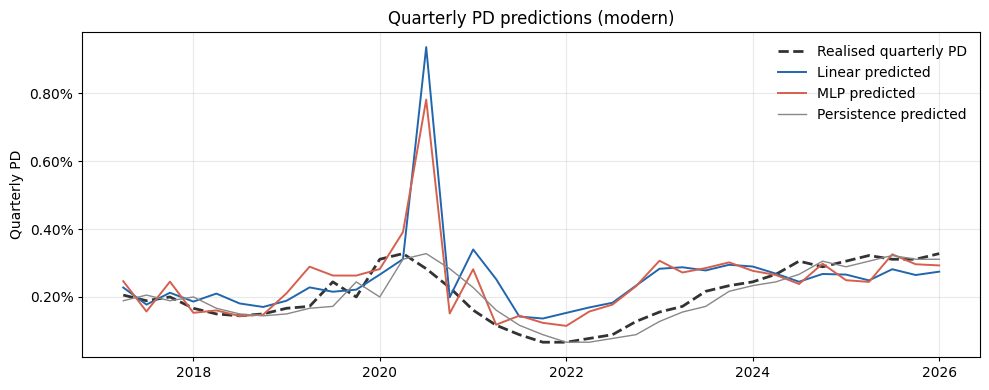

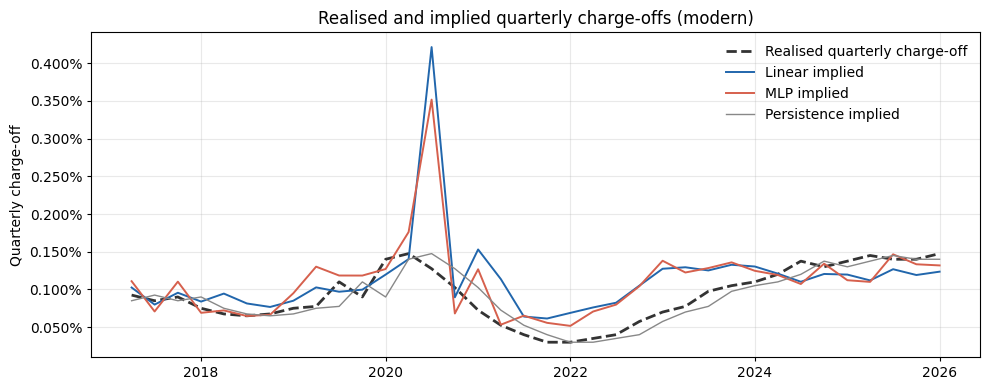

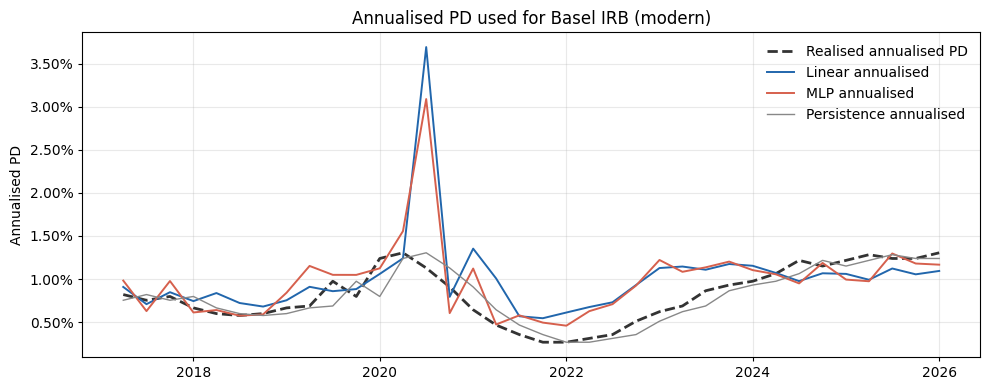

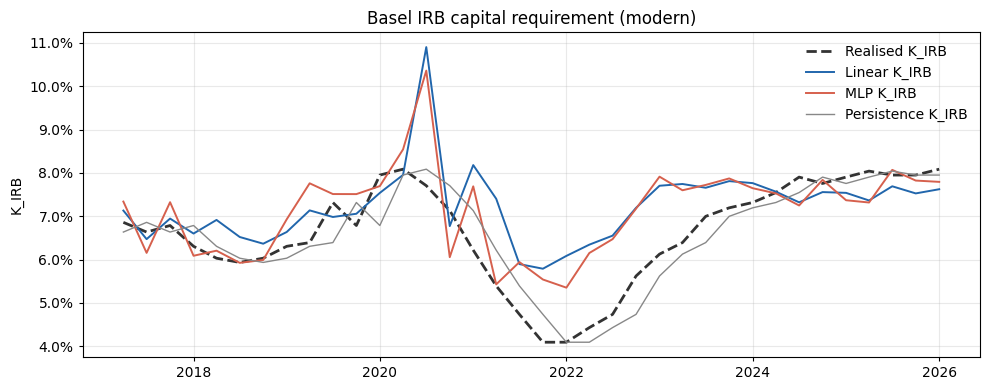

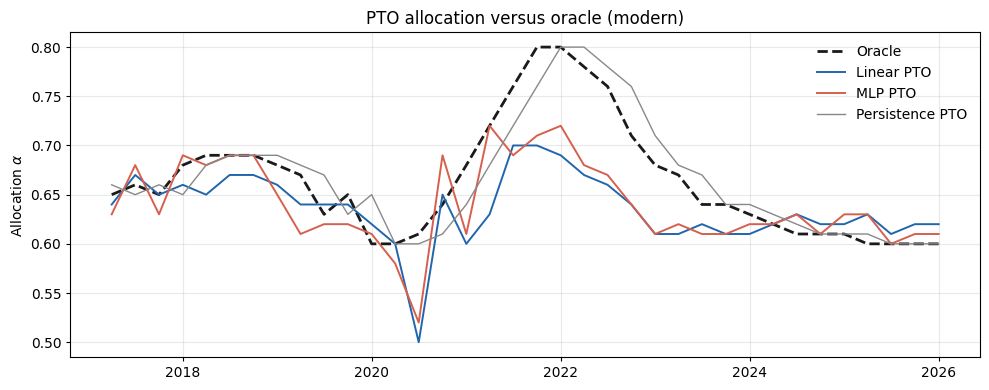

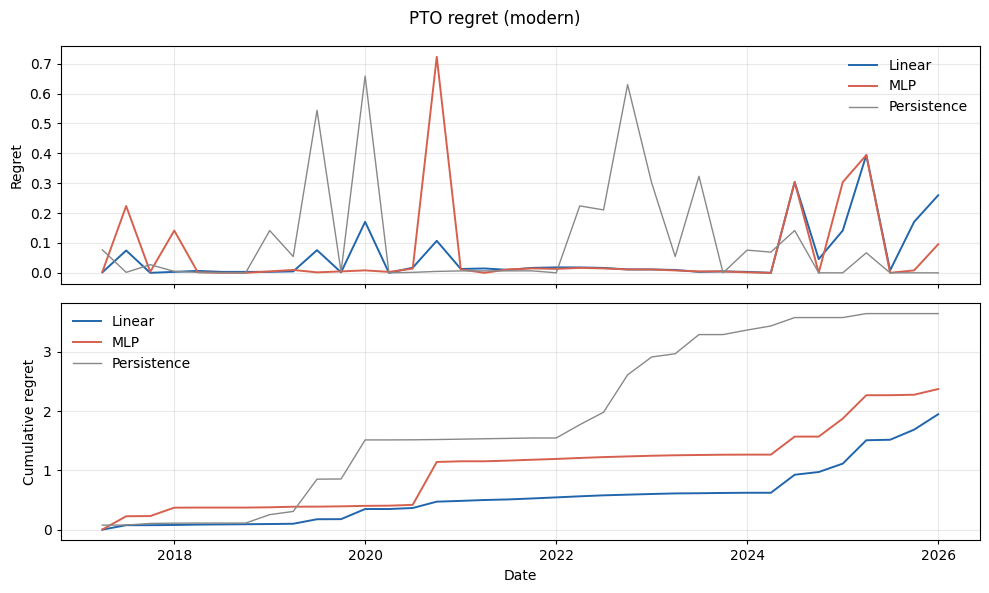

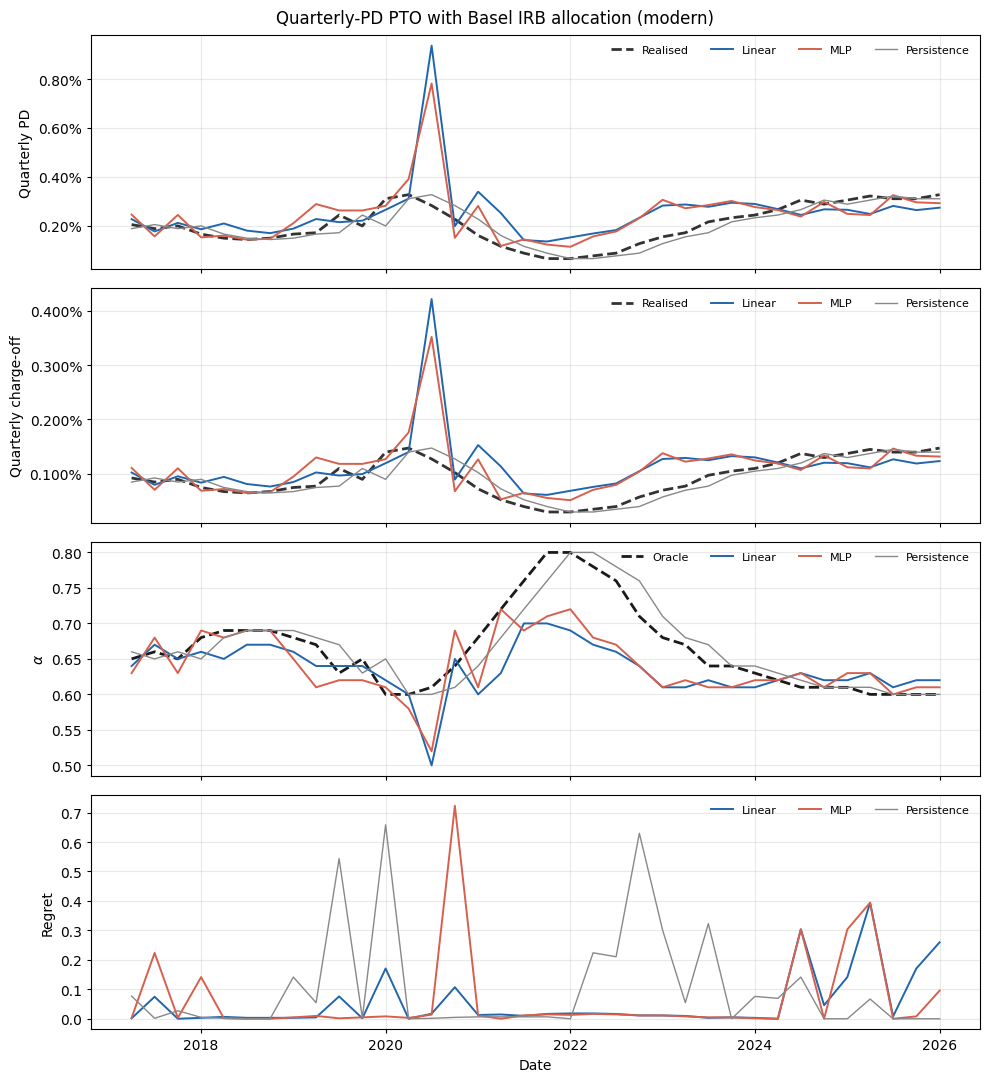

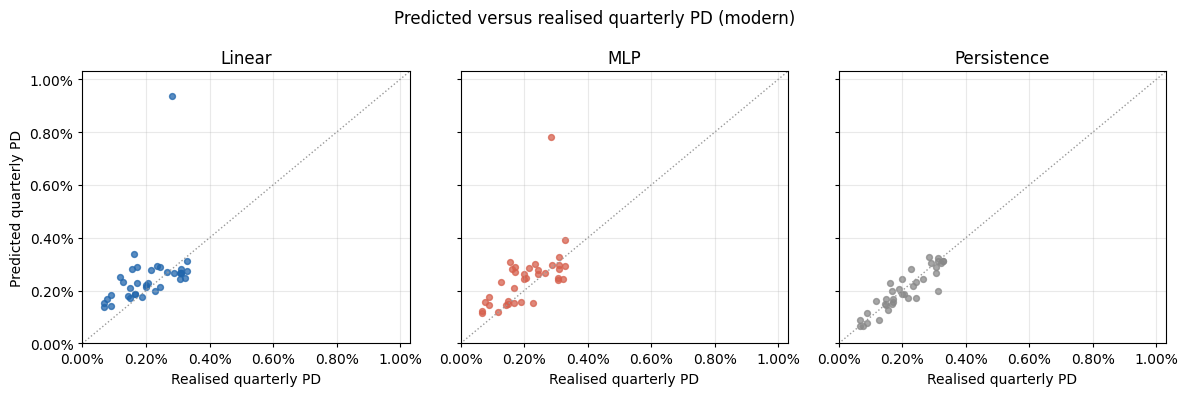

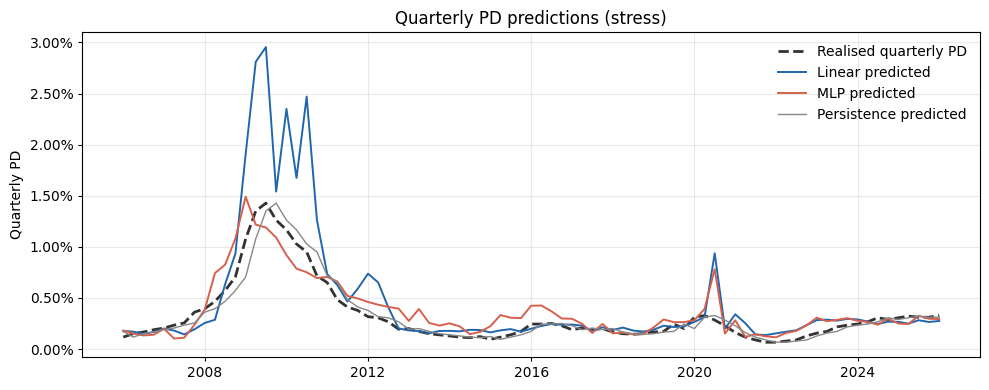

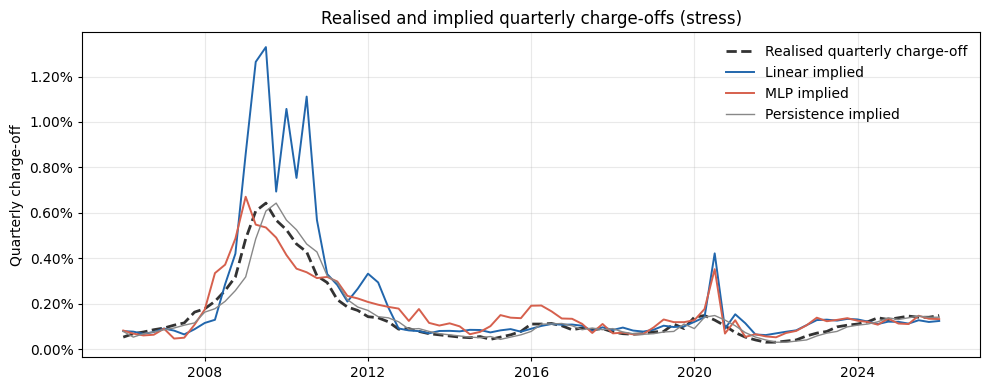

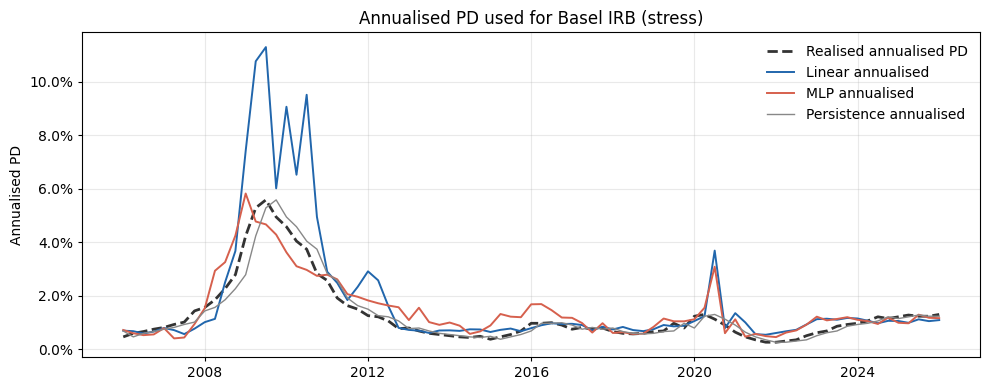

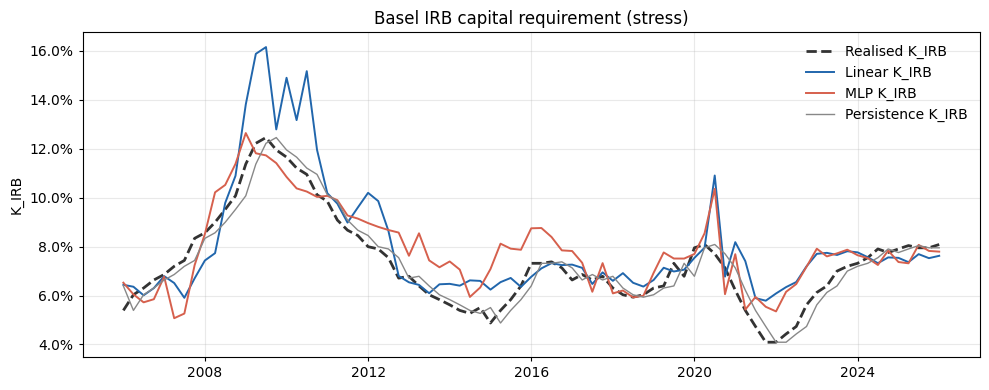

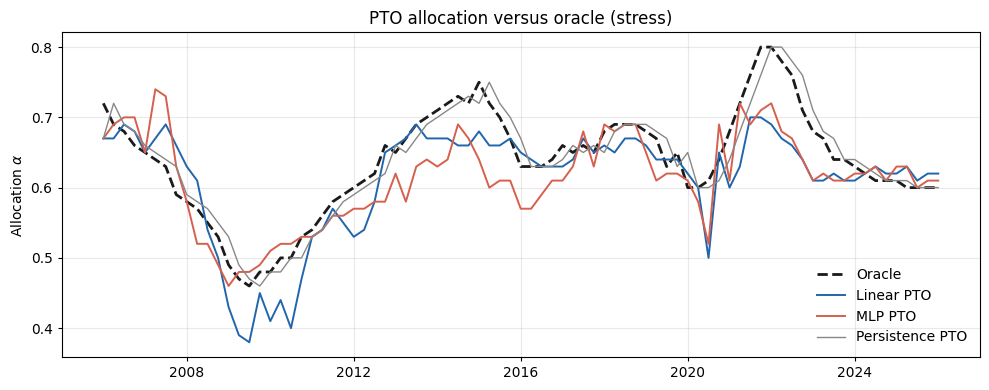

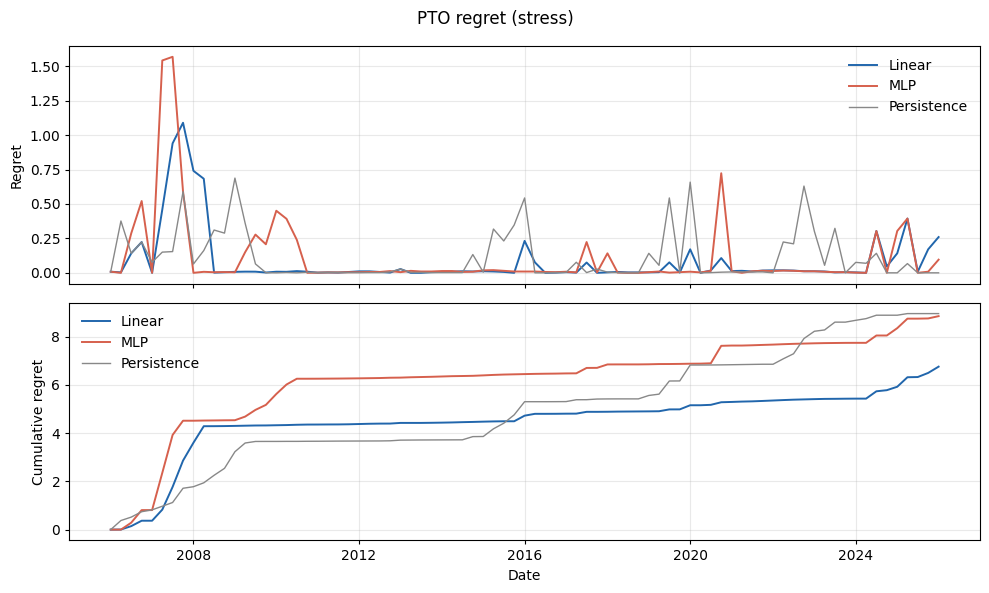

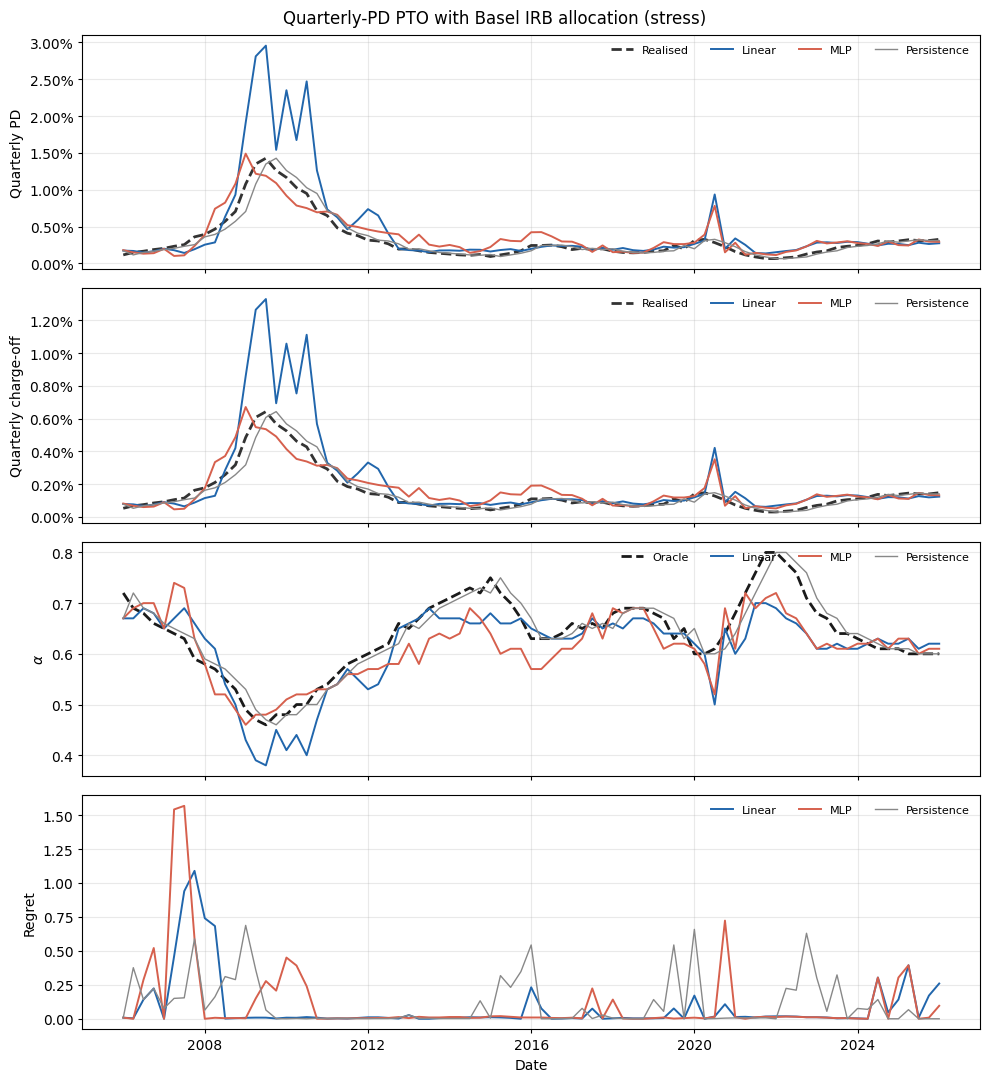

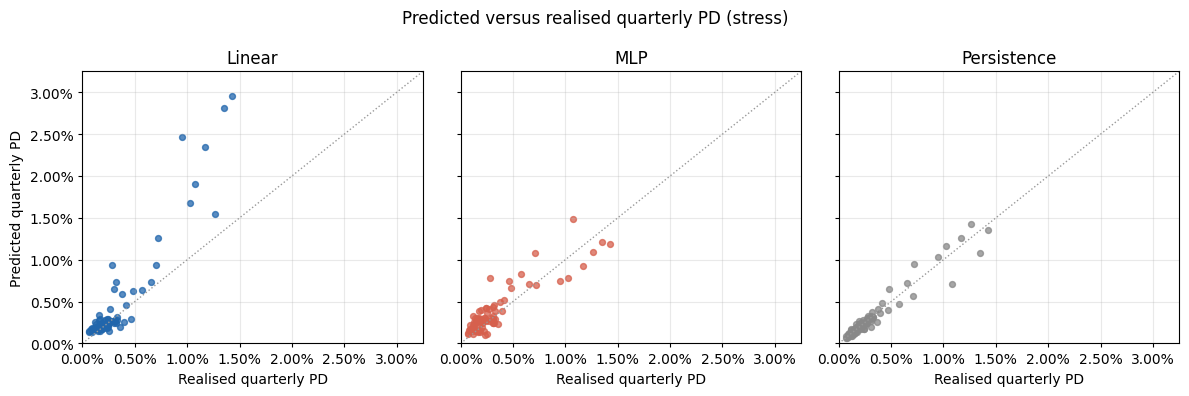

In [15]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d", "persistence": "#888888"}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "persistence": 1.0}
MODEL_LABELS = {"linear": "Linear", "mlp": "MLP", "persistence": "Persistence"}
ORACLE_COLOR = "#1a1a1a"
REAL_COLOR = "#333333"

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix=""):
    for m in MODEL_ORDER:
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    # 1. Quarterly PD predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD predictions ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Quarterly charge-off predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
    _model_lines(ax, plot_df, "c_q_hat", " implied")
    ax.set_ylabel("Quarterly charge-off"); ax.set_title(f"Realised and implied quarterly charge-offs ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Annualised PD for IRB
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
    _model_lines(ax, plot_df, "pd_a_hat", " annualised")
    ax.set_ylabel("Annualised PD"); ax.set_title(f"Annualised PD used for Basel IRB ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. IRB capital requirement
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Allocation comparison
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat", " PTO")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"PTO allocation versus oracle ({split_name})")
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Regret and cumulative regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in MODEL_ORDER:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle(f"PTO regret ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "c_q_hat")
    axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in MODEL_ORDER:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Quarterly-PD PTO with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "pto_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 8. Predicted vs realised scatter
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_realised"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in MODEL_ORDER)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), MODEL_ORDER):
        ax.scatter(plot_df["pd_q_realised"], plot_df[f"pd_q_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot(lims, lims, color="#999999", lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("Realised quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle(f"Predicted versus realised quarterly PD ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_realised_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)

## Learning curves

Averaged across expanding windows within each split; the MLP curve is the first ensemble
seed only.

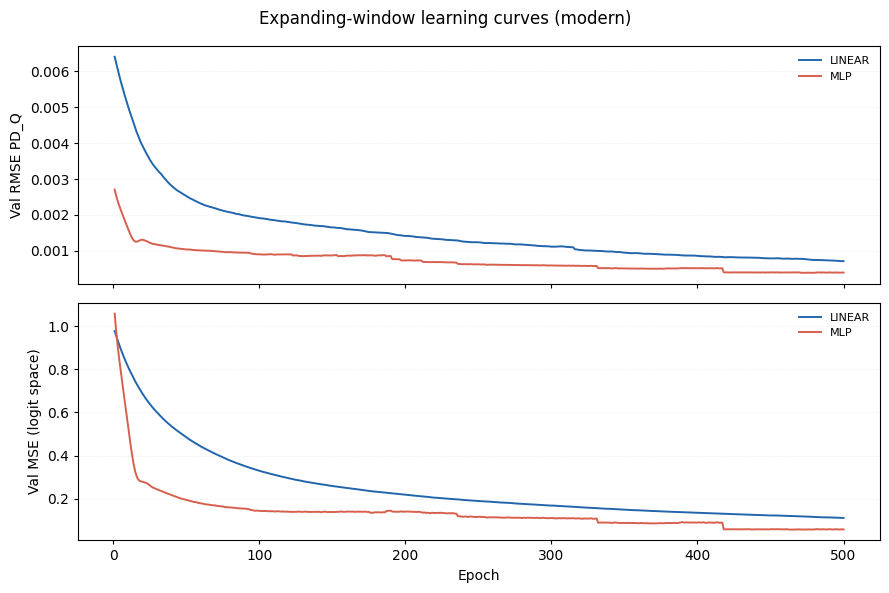

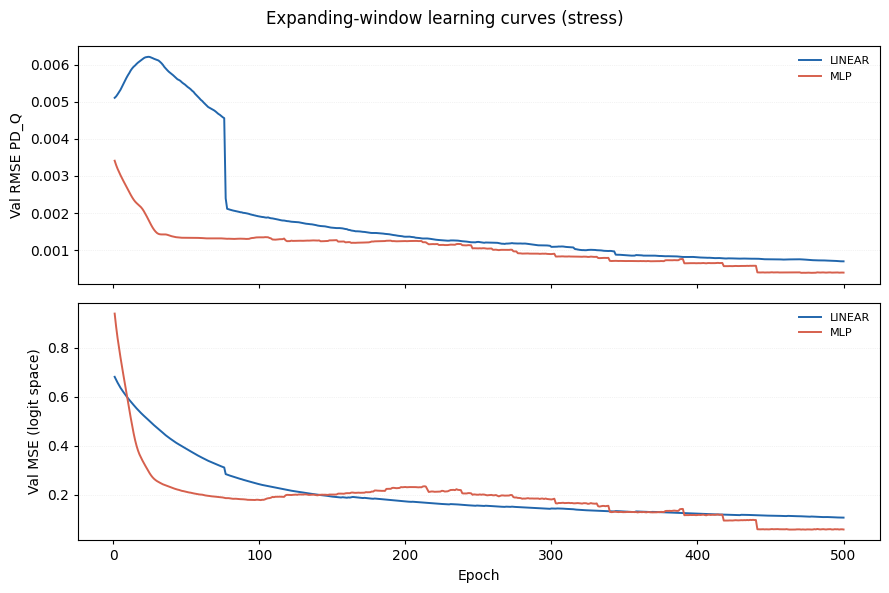

In [16]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        mean_history = split_hist.groupby(["model", "epoch"], as_index=False).agg(
            mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean"))
        fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=model_name.upper())
            axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=model_name.upper())
        axes[0].set_ylabel("Val RMSE PD_Q")
        axes[1].set_ylabel(f"Val MSE ({TARGET_TRANSFORM} space)"); axes[1].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()